# Notebook 01 - Validação do modelo e gráficos

Notebook para gerar curva Top-K, churn por safra e tabelas de validação.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa


try:
    pa.unregister_extension_type("pandas.period")
except Exception:
    pass


for candidate in [Path.cwd().resolve(), Path.cwd().resolve().parent]:
    if (candidate / "data" / "processed" / "scores_test.parquet").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Nao encontrei data/processed a partir do diretorio atual do notebook")

SCORES_TEST = PROJECT_ROOT / "data" / "processed" / "scores_test.parquet"
MODEL_TABLE = PROJECT_ROOT / "data" / "processed" / "model_table"
if not MODEL_TABLE.exists():
    MODEL_TABLE = PROJECT_ROOT / "data" / "processed" / "model_table.parquet"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SCORES_TEST exists:", SCORES_TEST.exists(), SCORES_TEST)
print("MODEL_TABLE exists:", MODEL_TABLE.exists(), MODEL_TABLE)

# Carrega so as colunas necessarias para a curva inicial e evita abrir a tabela de 4+ GB na primeira celula.
scores = pd.read_parquet(
    SCORES_TEST,
    columns=["safra", "churn_3m", "p_churn"],
    engine="pyarrow",
)

scores["safra"] = pd.to_numeric(scores["safra"], errors="coerce").astype("int32")
scores["churn_3m"] = pd.to_numeric(scores["churn_3m"], errors="coerce").astype("int8")

print("scores shape:", scores.shape)
scores.head()

PROJECT_ROOT: /home/eragom/Documentos/case_datamaster/case_churn
SCORES_TEST exists: True /home/eragom/Documentos/case_datamaster/case_churn/data/processed/scores_test.parquet
MODEL_TABLE exists: True /home/eragom/Documentos/case_datamaster/case_churn/data/processed/model_table
scores shape: (8963385, 3)


,safra,churn_3m,p_churn
0,201606,0,0.142895
1,201606,0,0.094386
2,201606,0,0.090861
3,201606,1,0.140310
4,201606,0,0.071775


In [2]:
base_churn = scores["churn_3m"].mean()
print("Base churn TEST:", round(base_churn, 6))

Base churn TEST: 0.047393


In [3]:
def recall_at_k(y_true, y_score, frac):
    k = max(1, int(len(y_true) * frac))
    idx = np.argsort(-y_score)[:k]
    return float(y_true.iloc[idx].sum() / y_true.sum()), k

def churnrate_at_k(y_true, y_score, frac):
    k = max(1, int(len(y_true) * frac))
    idx = np.argsort(-y_score)[:k]
    return float(y_true.iloc[idx].mean()), k

rows = []
for frac in [0.01, 0.03, 0.05, 0.10, 0.20]:
    rec, k = recall_at_k(scores["churn_3m"], scores["p_churn"], frac)
    cr, _ = churnrate_at_k(scores["churn_3m"], scores["p_churn"], frac)
    rows.append({"top_frac": frac, "k": k, "recall": rec, "churn_rate": cr})

curve = pd.DataFrame(rows)
curve["lift"] = curve["churn_rate"] / base_churn
curve

,top_frac,k,recall,churn_rate,lift
0,0.01,89633,0.002893,0.013711,0.289311
1,0.03,268901,0.010572,0.016701,0.352397
2,0.05,448169,0.073010,0.069204,1.460197
3,0.10,896338,0.193006,0.091472,1.930059
4,0.20,1792677,0.643826,0.152566,3.219128


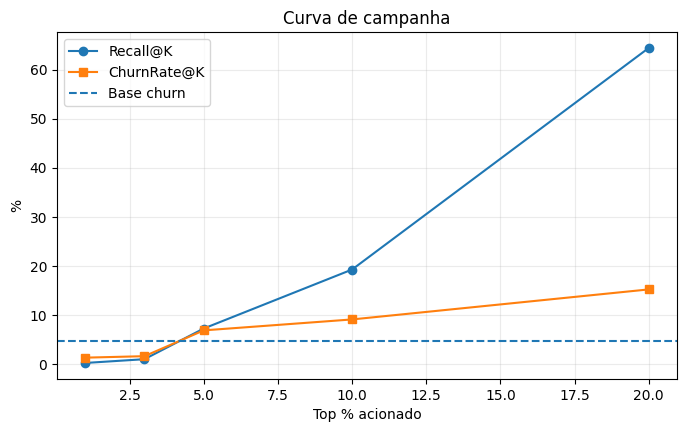

In [4]:
plt.figure(figsize=(8,4.5))
plt.plot(curve["top_frac"]*100, curve["recall"]*100, marker="o", label="Recall@K")
plt.plot(curve["top_frac"]*100, curve["churn_rate"]*100, marker="s", label="ChurnRate@K")
plt.axhline(base_churn*100, linestyle="--", label="Base churn")
plt.xlabel("Top % acionado")
plt.ylabel("%")
plt.title("Curva de campanha")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [5]:
df = pd.read_parquet(
    MODEL_TABLE,
    columns=["safra", "churn_3m", "is_ativo", "label_trust"],
    engine="pyarrow",
)
df["safra"] = pd.to_numeric(df["safra"], errors="coerce").astype("int32")
df["churn_3m"] = pd.to_numeric(df["churn_3m"], errors="coerce").fillna(0).astype("int8")
df["is_ativo"] = pd.to_numeric(df["is_ativo"], errors="coerce").fillna(0).astype("int8")
df["label_trust"] = pd.to_numeric(df["label_trust"], errors="coerce").fillna(0).astype("int8")

trusted = df[(df["is_ativo"] == 1) & (df["label_trust"] == 1)].copy()
churn_by_month = trusted.groupby("safra", as_index=False)["churn_3m"].mean()
churn_by_month

,safra,churn_3m
0,201601,0.139944
1,201602,0.140160
2,201603,0.078067
3,201604,0.045341
4,201605,0.048684
5,201606,0.049240
6,201607,0.033494
7,201608,0.056631
8,201609,0.050325


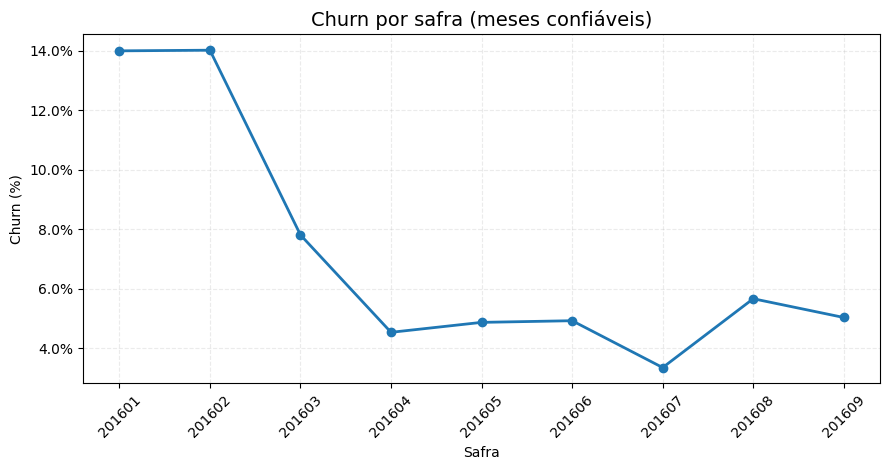

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# churn_by_month precisa ter as colunas: safra e churn_3m
# Exemplo:
# churn_by_month = trusted.groupby("safra", as_index=False)["churn_3m"].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    churn_by_month["safra"].astype(str),
    churn_by_month["churn_3m"] * 100,
    marker="o",
    linewidth=2,
)

ax.set_title("Churn por safra (meses confiáveis)", fontsize=14)
ax.set_xlabel("Safra")
ax.set_ylabel("Churn (%)")

# grade mais suave
ax.grid(alpha=0.25, linestyle="--")

# força mostrar cada safra no eixo X
ax.set_xticks(range(len(churn_by_month)))
ax.set_xticklabels(churn_by_month["safra"].astype(str), rotation=45)

# mostra % no eixo Y
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()